<a href="https://colab.research.google.com/github/NoraFlamez/Tugas-Fundamental-Data-Analyst/blob/main/Prediksi%20sesuai%20pada%20modul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer # Import KBinsDiscretizer
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
url = "https://raw.githubusercontent.com/NoraFlamez/Tugas-Fundamental-Data-Analyst/refs/heads/main/Student_performance_data%20_.csv"
column_names = ['StudentId', 'Age', 'Ethnicity','ParentalEducation','StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sport', 'Music', 'Volunteering', 'GPA', 'GradeClass']
data = pd.read_csv(url, names=column_names, header=None)

# Hapus baris pertama yang kemungkinan merupakan header asli.
data = data.iloc[1:].copy()

# Konversikan semua kolom menjadi numerik, memaksa kesalahan
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Hapus baris yang mengandung nilai NaN yang dihasilkan oleh pemaksaan tipe data jika ada.
data.dropna(inplace=True)

data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2392 entries, 1001 to 3392
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentId          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Ethnicity          2392 non-null   int64  
 3   ParentalEducation  2392 non-null   int64  
 4   StudyTimeWeekly    2392 non-null   float64
 5   Absences           2392 non-null   int64  
 6   Tutoring           2392 non-null   int64  
 7   ParentalSupport    2392 non-null   int64  
 8   Extracurricular    2392 non-null   int64  
 9   Sport              2392 non-null   int64  
 10  Music              2392 non-null   int64  
 11  Volunteering       2392 non-null   int64  
 12  GPA                2392 non-null   float64
 13  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(11)
memory usage: 280.3+ KB


,StudentId,Age,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sport,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [29]:
# Periksa apakah ada nilai yang kosong
print(data.isnull().values.any())

False


In [30]:
# Periksa data isnull perkolom
print(data.isnull().sum())

StudentId            0
Age                  0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sport                0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [31]:
# Mengisi nilai yang hilang missing values
data = data.fillna(data.mean(numeric_only=True))
print(data.isnull().sum())

StudentId            0
Age                  0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sport                0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [32]:
# Memilih Fitur (Features) dan Target
features = ['Age', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sport', 'Music', 'Volunteering', 'GPA']
target = 'GradeClass'
X = data[features]
y = data[target]

In [34]:
# Diskritisasi Target menjadi beberapa kelas
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
y_discretized = discretizer.fit_transform(y.values.reshape(-1, 1)).flatten()
print("data target setelah diskritisasi")
print(y_discretized)

# Untuk mengetahui nilai nilai unique hasil diskrit
unique_values = set(y_discretized)
print("Nilai unik setelah diskritisasi:", unique_values)

# Untuk mengetahui nilai detail hasil diskrit
for bin_idx in range(4):
  bin_mask = (y_discretized == bin_idx)
  print(f"Bin {bin_idx}: {y[bin_mask]}")

data target setelah diskritisasi
[1. 0. 2. ... 1. 0. 0.]
Nilai unik setelah diskritisasi: {np.float64(0.0), np.float64(1.0), np.float64(2.0)}
Bin 0: 1002    1.0
1006    1.0
1010    0.0
1039    1.0
1045    0.0
       ... 
3382    0.0
3386    1.0
3388    0.0
3391    1.0
3392    1.0
Name: GradeClass, Length: 376, dtype: float64
Bin 1: 1001    2.0
1007    2.0
1009    2.0
1021    2.0
1026    2.0
       ... 
3364    2.0
3366    2.0
3367    2.0
3378    2.0
3390    2.0
Name: GradeClass, Length: 391, dtype: float64
Bin 2: 1003    4.0
1004    3.0
1005    4.0
1008    4.0
1011    3.0
       ... 
3383    3.0
3384    3.0
3385    4.0
3387    4.0
3389    4.0
Name: GradeClass, Length: 1625, dtype: float64
Bin 3: Series([], Name: GradeClass, dtype: float64)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [36]:
# Bagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y_discretized, test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1913, 10)
Shape of X_test: (479, 10)
Shape of y_train: (1913,)
Shape of y_test: (479,)


In [39]:
# Menghitung baseline performance (prediksi kelas mayoritas)
# Mencari kelas mayoritas
y_train = y_train.astype(int)
# Konversi nilai data agar dihitung kelas dengan populasi terbanyak
majority_class = np.bincount(y_train).argmax()
# Prediksi kelas mayoritas pada testing tes
y_pred_baseline = np.full(y_test.shape, majority_class)

In [40]:
# Inisialisasi model
model = DecisionTreeClassifier(random_state=42)
# Latih model menggunakan data latih
model.fit(X_train, y_train)
# Lakukan prediksi pada data uji
y_pred = model.predict(X_test)

In [46]:
# Hitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
labels = ['Low', 'Medium', ' High']
# Menghitung akurasi baseline
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print("Baseline Accuracy:", baseline_accuracy, "\n")
print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Precision", precision,"\n")
# Tampilkab confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Baseline Accuracy: 0.6743215031315241 

Decision Tree Accuracy: 0.8768267223382046
Decision Tree Precision 0.8773786525491553 

Confusion Matrix:
[[ 53   4  14]
 [  4  68  13]
 [ 17   7 299]]


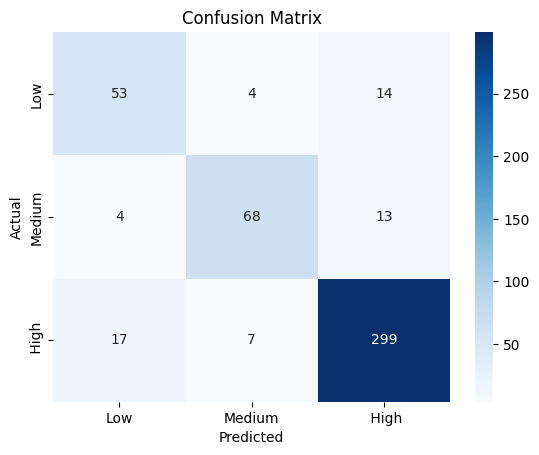

              precision    recall  f1-score   support

         0.0       0.72      0.75      0.73        71
         1.0       0.86      0.80      0.83        85
         2.0       0.92      0.93      0.92       323

    accuracy                           0.88       479
   macro avg       0.83      0.82      0.83       479
weighted avg       0.88      0.88      0.88       479



In [47]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
# Tampilkan classification report
print(classification_report(y_test, y_pred))
